In [3]:
import numpy
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
df0=pd.read_csv('/mnt/sda2/extragalactica/4_practico/densidad.csv')
df0.head()
sns.set_palette('pastel',3)
histograma = pd.read_fwf('/mnt/sda2/extragalactica/4_practico/bines.dat',names=['rho_medio', 'total', 'e', 'l', 's'])

Recordar que '1' = espiral , '2'= lenticular, '3'= eliptica, '4'= indefinido -> NO USAR


Esto que hice abajo en realidad hay que hacerlo en fortran ='C 

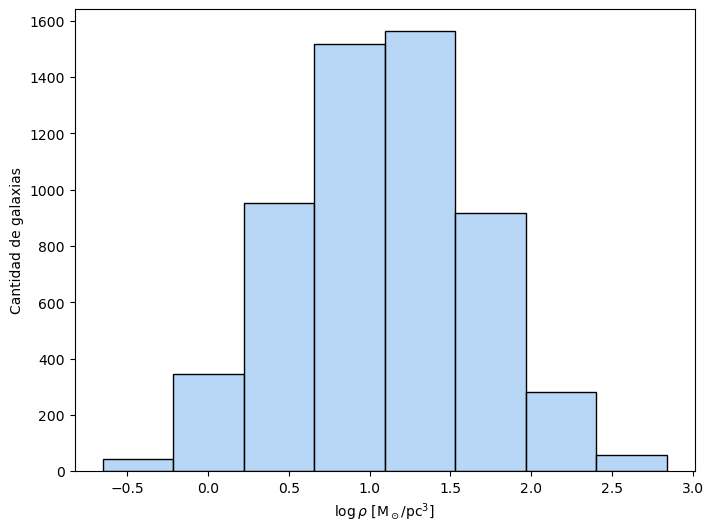

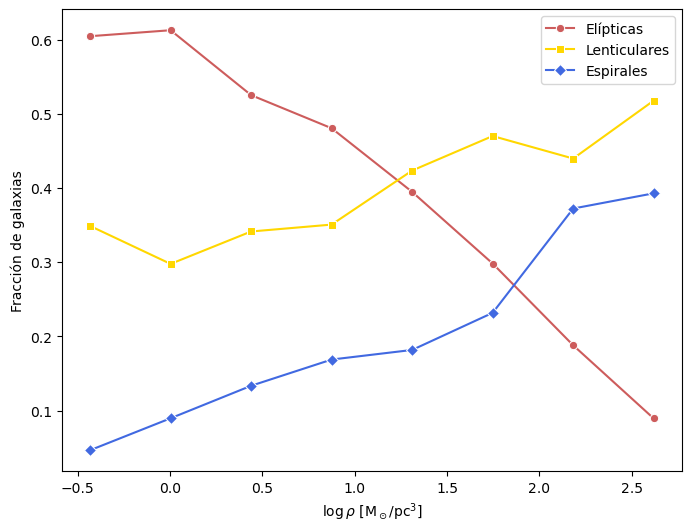

In [4]:
cant_bin=8
df=df0[df0['tipo']!= 4]
plt.figure(figsize=(8,6))
sns.histplot(data=df, x='logrho',bins=cant_bin)
plt.xlabel(r'$\log \rho$ [M$_\odot$/pc$^3$]')
plt.ylabel('Cantidad de galaxias')
plt.savefig('/mnt/sda2/extragalactica/4_practico/informe/imagenes/hist_rho.pdf', dpi=300, bbox_inches='tight')
plt.show()

elip= df[df['tipo']==3]
lent= df[df['tipo']==2]
esp= df[df['tipo']==1]

cuentas_elip=0
cant_total, bins = numpy.histogram(df['logrho'], bins=cant_bin) # obtengo los bins para usarlos despues
#np.histogram realiza todo el conteo y los bines sin hacer el grafico
cuentas_elip, _ = numpy.histogram(elip['logrho'], bins=bins)
cuentas_lent, _ = numpy.histogram(lent['logrho'], bins=bins)
cuentas_esp, _ = numpy.histogram(esp['logrho'], bins=bins)

centros = (bins[:-1] + bins[1:]) / 2 # calcular los centros de los bins, no uso los bordes xq tengo un elemento de mas

plt.figure(figsize=(8,6))
sns.lineplot(x=centros, y=cuentas_elip/cant_total,color='indianred' ,label='Elípticas', marker='o')
sns.lineplot(x=centros, y=cuentas_lent/cant_total, color='gold', label='Lenticulares', marker='s')
sns.lineplot(x=centros, y=cuentas_esp/cant_total, color='royalblue', label='Espirales', marker='D')
plt.xlabel(r'$\log \rho$ [M$_\odot$/pc$^3$]')
plt.ylabel('Fracción de galaxias')
plt.savefig('/mnt/sda2/extragalactica/4_practico/informe/imagenes/rho_tipo.pdf', dpi=300, bbox_inches='tight')
plt.show()

En Dressler 1980, une el histograma de log($\rho$) con las curvas para cada tipo de galaxia en función de la densidad, para compararlo, lo hago abajo

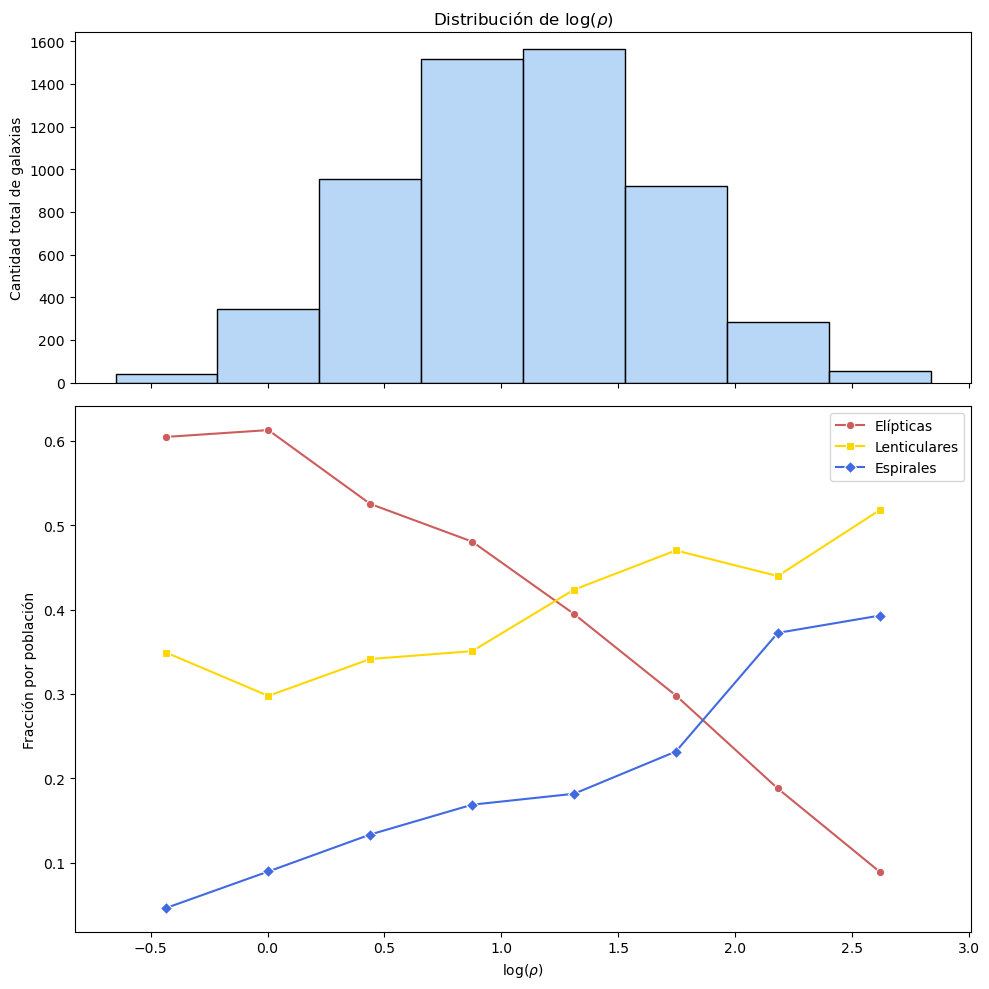

In [78]:

# Crear subplots compartiendo el eje x
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), sharex=True, 
                               gridspec_kw={'height_ratios': [1, 1.5]})

# Subplot superior: Histograma
sns.histplot(data=df, x='logrho', bins=cant_bin, ax=ax1)
ax1.set_ylabel('Cantidad total de galaxias')
ax1.set_xlabel('')  # Quitar xlabel del subplot superior
ax1.set_title(r'Distribución de log($\rho$)')

# Subplot inferior: Líneas por tipo
sns.lineplot(x=centros, y=cuentas_elip/cant_total, color='indianred', 
             label='Elípticas', marker='o', ax=ax2)
sns.lineplot(x=centros, y=cuentas_lent/cant_total, color='gold', 
             label='Lenticulares', marker='s', ax=ax2)
sns.lineplot(x=centros, y=cuentas_esp/cant_total, color='royalblue', 
             label='Espirales', marker='D', ax=ax2)

ax2.set_xlabel(r'log($\rho$)')
ax2.set_ylabel('Fracción por población')
ax2.legend()

plt.tight_layout()
plt.savefig('/mnt/sda2/extragalactica/4_practico/informe/imagenes/hist_y_tipos_combined.pdf', 
            dpi=300, bbox_inches='tight')
plt.show()

In [4]:
histograma.columns

Index(['rho_medio', 'total', 'e', 'l', 's'], dtype='object')

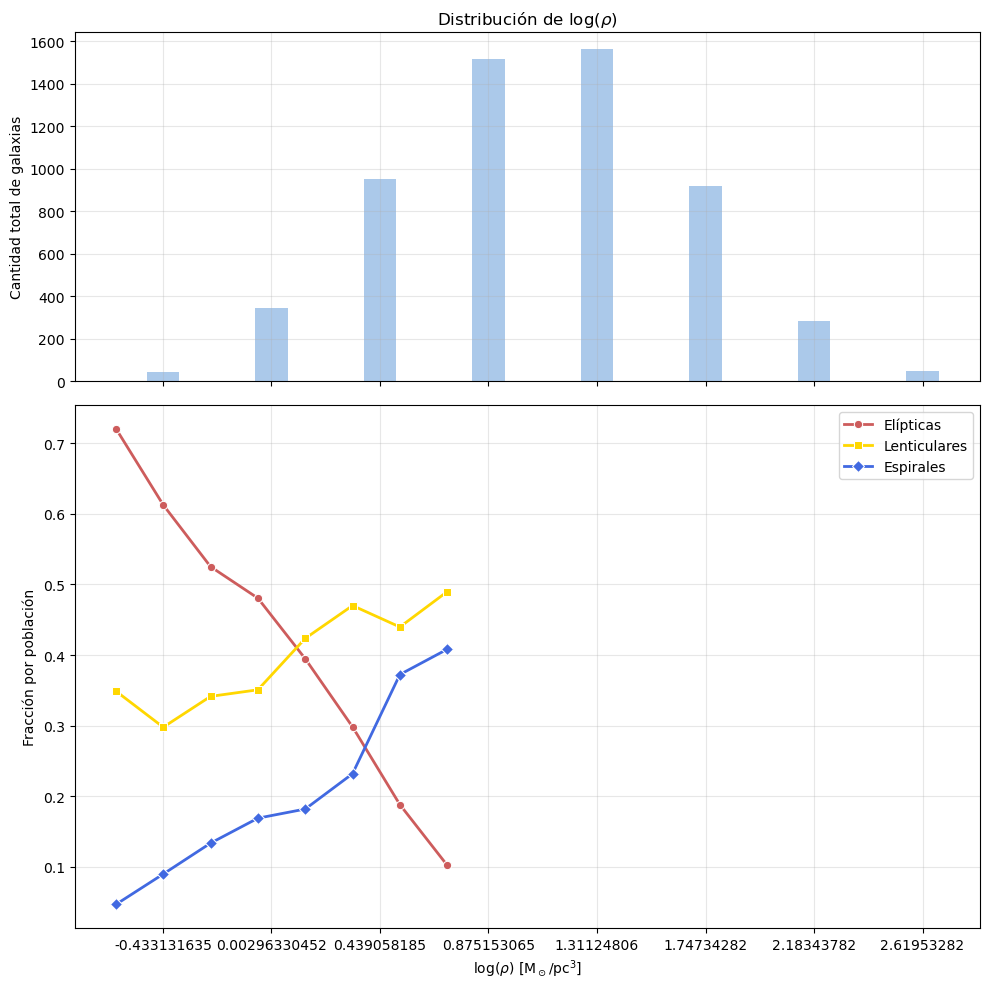

In [10]:

# Crear subplots compartiendo el eje x
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), sharex=True, 
                               gridspec_kw={'height_ratios': [1, 1.5]})

# Subplot superior: Histograma
sns.barplot(data=histograma, x='rho_medio', y='total', ax=ax1,width=0.3)
ax1.set_ylabel('Cantidad total de galaxias')
ax1.set_xlabel('')  # Quitar xlabel del subplot superior
ax1.set_title(r'Distribución de log($\rho$)')

# Subplot inferior: Líneas por tipo
sns.lineplot(x=histograma['rho_medio'], y=histograma['e'], color='indianred', 
             label='Elípticas', marker='o', ax=ax2, linewidth=2, markersize=6)
sns.lineplot(x=histograma['rho_medio'], y=histograma['l'], color='gold', 
             label='Lenticulares', marker='s', ax=ax2, linewidth=2, markersize=6)
sns.lineplot(x=histograma['rho_medio'], y=histograma['s'], color='royalblue', 
             label='Espirales', marker='D', ax=ax2, linewidth=2, markersize=6)


ax2.set_xlabel(r'log($\rho$) [M$_\odot$/pc$^3$]')
ax2.set_ylabel('Fracción por población')
ax2.legend()

# Mejorar la grilla
ax1.grid(True, alpha=0.3)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/mnt/sda2/extragalactica/4_practico/informe/imagenes/hist_y_tipos_combined.pdf', 
            dpi=300, bbox_inches='tight')
plt.show()

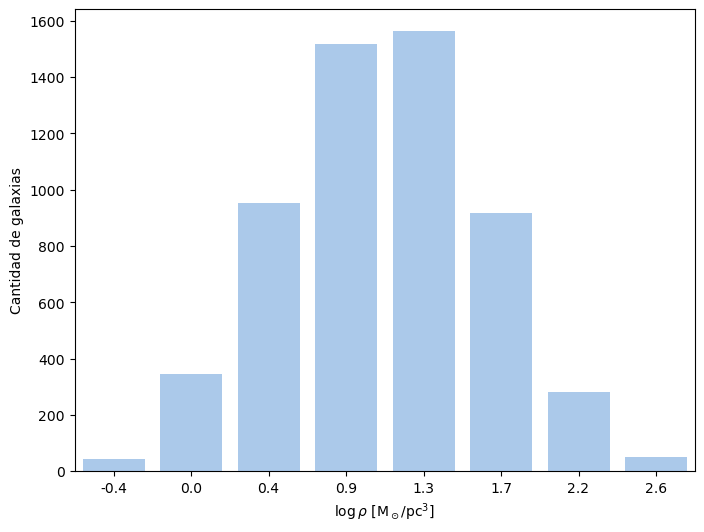

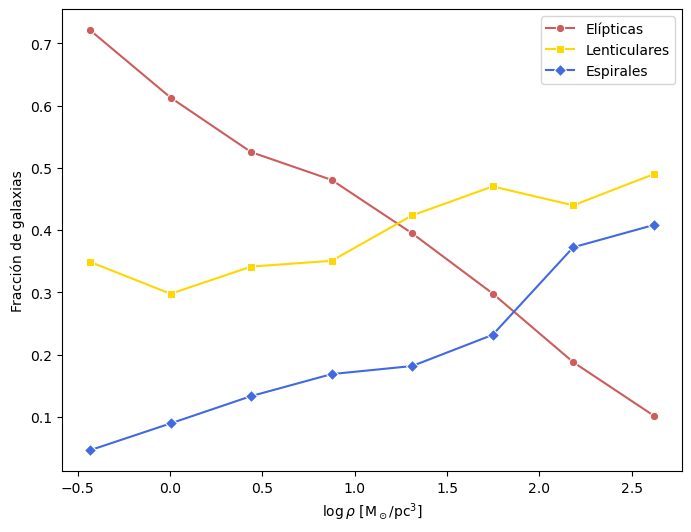

In [14]:

plt.figure(figsize=(8,6))
sns.barplot(data=histograma, x='rho_medio', y='total')
plt.xlabel(r'$\log \rho$ [M$_\odot$/pc$^3$]')
plt.ylabel('Cantidad de galaxias')
plt.xticks(ticks=range(len(histograma)), labels=[f'{x:.1f}' for x in histograma['rho_medio']])
plt.savefig('/mnt/sda2/extragalactica/4_practico/informe/imagenes/hist_rho.pdf', dpi=300, bbox_inches='tight')
plt.show()

plt.figure(figsize=(8,6))
sns.lineplot(data=histograma, x='rho_medio', y='e',color='indianred' ,label='Elípticas', marker='o')
sns.lineplot(data=histograma, x='rho_medio', y='l', color='gold', label='Lenticulares', marker='s')
sns.lineplot(data=histograma, x='rho_medio', y='s', color='royalblue', label='Espirales', marker='D')
plt.xlabel(r'$\log \rho$ [M$_\odot$/pc$^3$]')
plt.ylabel('Fracción de galaxias')
plt.savefig('/mnt/sda2/extragalactica/4_practico/informe/imagenes/rho_tipo.pdf', dpi=300, bbox_inches='tight')
plt.show()